In [4]:
import kagglehub
import os
import shutil

data_dir = os.path.join(os.getcwd(), "content", "louisiana_images")
key_file = os.path.join(data_dir, "train.csv")

if not os.path.exists(key_file):
    path = kagglehub.dataset_download("rahultp97/louisiana-flood-2016")

    os.makedirs(data_dir, exist_ok=True)

    shutil.copytree(path, data_dir, dirs_exist_ok=True)

    print(f"Dataset copiado de {path} para {data_dir}")
else:
    print(f"Dataset encontrado em {data_dir}")


Dataset encontrado em c:\Projetos\Aula\ia_e_ml\college-AI-ML\desafio2\content\louisiana_images


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import to_categorical
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [ ]:
train_df = pd.read_csv(data_dir + '/train.csv')
test_df = pd.read_csv(data_dir + '/test.csv')

Colunas do CSV: ['Image ID', 'Normal', 'Flooded']
      Image ID  Normal  Flooded
0   2004_0.png       0        0
1   2008_0.png       0        0
2    11006.png       1        0
3  10005_0.png       0        0
4  15003_0.png       0        0


In [10]:
import tensorflow as tf
import os

image_size = (512, 360)
batch_size = 32

def preprocess_image_py(image_path_tensor, label):
    image_path = image_path_tensor.numpy().decode('utf-8')
    try:
        img = tf.io.read_file(image_path)
        img = tf.image.decode_image(img, channels=3)
        if img.shape.rank == 0:  # Verifica se a imagem está vazia
            raise ValueError(f"imagem vazia")
        img = tf.image.resize(img, image_size)
        img = tf.cast(img, tf.float32) / 255.0  # Normaliza para o intervalo [0, 1]
        return img, label
    except Exception as e:
        print(f"Erro ao processar a imagem {image_path}: {e}")
        # Retorna uma imagem preta preenchida com zeros como substituta
        return tf.zeros((*image_size, 3), dtype=tf.float32), label

def preprocess_image(image_path, label):
    processed_image, processed_label = tf.py_function(
        preprocess_image_py,
        inp=[image_path, label],
        Tout=[tf.float32, label.dtype]
    )
    processed_image.set_shape([*image_size, 3])
    processed_label.set_shape([])
    return processed_image, processed_label

# --- Criar Dataset de Treino ---
print("Criando dataset de treino...")
train_image_filenames = train_df['Image ID'].values
train_labels = train_df['Flooded'].values

train_image_paths = [os.path.join(data_dir, 'train', fname) for fname in train_image_filenames]

train_ds = tf.data.Dataset.from_tensor_slices((train_image_paths, train_labels))

train_ds = train_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=len(train_image_paths)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# --- Criar Dataset de Teste ---
print("Criando dataset de teste...")
test_image_filenames = test_df['Image ID'].values
test_labels = test_df['Flooded'].values

test_image_paths = [os.path.join(data_dir, 'test', fname) for fname in test_image_filenames]

test_ds = tf.data.Dataset.from_tensor_slices((test_image_paths, test_labels))
test_ds = test_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE) # Não embaralha o conjunto de teste

print("Datasets de treino e teste criados com sucesso.")
print(f"Número de amostras de treino: {len(train_image_paths)}")
print(f"Número de amostras de teste: {len(test_image_paths)}")

# Opcional: Verificar um batch do dataset de treino
for images, labels in train_dataset.take(1):
    print(f"Formato do batch de imagens de treino: {images.shape}")
    print(f"Formato do batch de labels de treino: {labels.shape}")
    print(f"Tipo de dados do batch de imagens de treino: {images.dtype}")
    print(f"Tipo de dados do batch de labels de treino: {labels.dtype}")
    break

Criando dataset de treino...
Criando dataset de teste...
Datasets de treino e teste criados com sucesso.
Número de amostras de treino: 270
Número de amostras de teste: 52
Formato do batch de imagens de treino: (32, 512, 360, 3)
Formato do batch de labels de treino: (32,)
Tipo de dados do batch de imagens de treino: <dtype: 'float32'>
Tipo de dados do batch de labels de treino: <dtype: 'int64'>


In [11]:
for imgs, labels in train_ds.take(1):
    print("Valor mínimo:", tf.reduce_min(imgs).numpy())
    print("Valor máximo:", tf.reduce_max(imgs).numpy())

Valor mínimo: 0.0
Valor máximo: 1.0


In [ ]:
from keras.applications import MobileNet
from keras.models import Model
from keras.layers import Dense, Flatten, Dropout
from keras.optimizers import Adam
from tensorflow.keras import layers

base_model = MobileNet(
    include_top=False,
    weights='imagenet',
    input_shape=(image_size[0], image_size[1], 3),  # Seu tamanho (512, 360, 3)
    alpha=1.0,
    depth_multiplier=1,
    dropout=0.001
)

# Congela as camadas do modelo base para não serem treinadas
base_model.trainable = False

x = base_model.output

# Camadas para classificação binária
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

# Cria o modelo final
model = Model(inputs=base_model.input, outputs=output_layer)

# Compila o modelo
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Exibe o resumo do modelo
model.summary()

print("Modelo de Transfer Learning criado e compilado com sucesso!")

C:\Users\victo\AppData\Local\Temp\ipykernel_22768\2368273794.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 512, 360, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 256, 180, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 256, 180, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 256, 180, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 256, 180, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 256, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 256, 180, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 256, 180, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 256, 180, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 256, 180, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 257, 181, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 128, 90, 64)    │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 128, 90, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 128, 90, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 128, 90, 128)   │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 128, 90, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 128, 90, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 128, 90, 128)   │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 128, 90, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 128, 90, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 128, 90, 128)   │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 128, 90, 128)   │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,229,889 (12.32 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

Modelo de Transfer Learning criado e compilado com sucesso!


# Treino do Modelo

In [43]:
# cria um checkpoint para salvar os pesos do melhor modelo encontrado no treinamento
checkpointer = ModelCheckpoint(filepath='model.weights.best.keras', verbose=1, save_best_only=True)

# treina o modelo
hist = model.fit(train_ds, epochs=100,
          validation_data=test_ds,
          callbacks=[checkpointer],
          verbose=2)

Epoch 1/100

Epoch 1: val_loss improved from None to 0.66751, saving model to model.weights.best.keras

Epoch 1: finished saving model to model.weights.best.keras
9/9 - 30s - 3s/step - accuracy: 0.6222 - loss: 0.6806 - val_accuracy: 0.6154 - val_loss: 0.6675
Epoch 2/100

Epoch 2: val_loss improved from 0.66751 to 0.65443, saving model to model.weights.best.keras

Epoch 2: finished saving model to model.weights.best.keras
9/9 - 20s - 2s/step - accuracy: 0.6074 - loss: 0.6749 - val_accuracy: 0.6346 - val_loss: 0.6544
Epoch 3/100

Epoch 3: val_loss improved from 0.65443 to 0.64279, saving model to model.weights.best.keras

Epoch 3: finished saving model to model.weights.best.keras
9/9 - 20s - 2s/step - accuracy: 0.6407 - loss: 0.6479 - val_accuracy: 0.6154 - val_loss: 0.6428
Epoch 4/100

Epoch 4: val_loss improved from 0.64279 to 0.63173, saving model to model.weights.best.keras

Epoch 4: finished saving model to model.weights.best.keras
9/9 - 20s - 2s/step - accuracy: 0.6630 - loss: 0.61

# Resultado
## Matriz de Confusão

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = []
y_pred = []
for images, labels in test_ds.unbatch().batch(1):
    pred = model.predict(images, verbose=0)
    y_true.append(labels.numpy()[0])
    y_pred.append(1 if pred[0][0] > 0.5 else 0)

print("Matriz de confusão:\n", confusion_matrix(y_true, y_pred))
print("\nRelatório por classe:")
print(classification_report(y_true, y_pred, target_names=['Não inundação', 'Inundação']))

Matriz de confusão:
 [[36  0]
 [ 4 12]]

Relatório por classe:
               precision    recall  f1-score   support

Não inundação       0.90      1.00      0.95        36
    Inundação       1.00      0.75      0.86        16

     accuracy                           0.92        52
    macro avg       0.95      0.88      0.90        52
 weighted avg       0.93      0.92      0.92        52



## Carregando os pesos do modelo treinado

In [12]:
model_path = "model.weights.best.keras"   # ou o caminho completo

model = tf.keras.models.load_model(model_path)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 512, 360, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 256, 180, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 256, 180, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 256, 180, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 256, 180, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 256, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 256, 180, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 256, 180, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 256, 180, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 256, 180, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 257, 181, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 128, 90, 64)    │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 128, 90, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 128, 90, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 128, 90, 128)   │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 128, 90, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 128, 90, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 128, 90, 128)   │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 128, 90, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 128, 90, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 128, 90, 128)   │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 128, 90, 128)   │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,231,941 (12.33 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

 Optimizer params: 2,052 (8.02 KB)

## Resultado

(52, 512, 360, 3) (52,)
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step


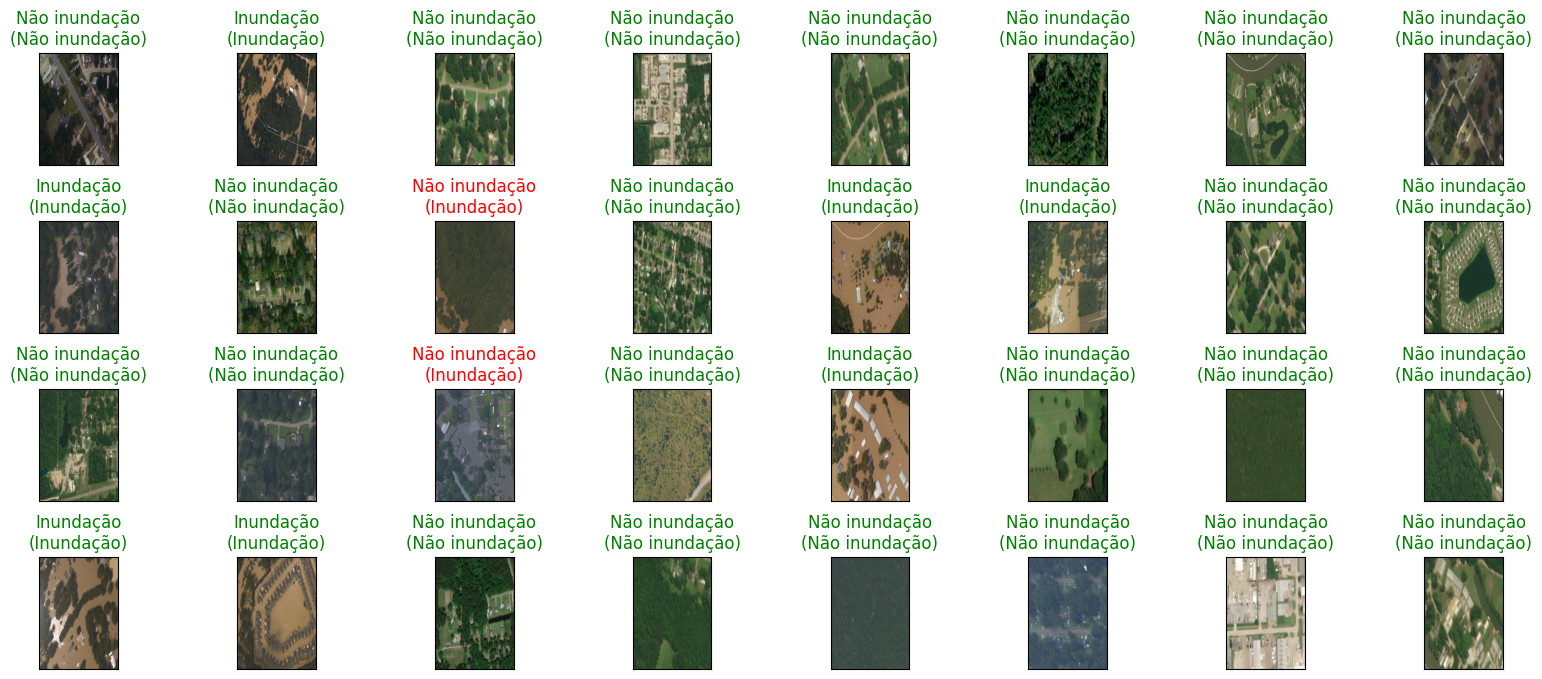

In [18]:
import numpy as np

# Listas para acumular
images_list = []
labels_list = []

for img_batch, lbl_batch in test_ds.unbatch().batch(1):
    images_list.append(img_batch.numpy()[0])
    labels_list.append(lbl_batch.numpy()[0])

# Converte para arrays
x_test = np.array(images_list)
y_test = np.array(labels_list)

print(x_test.shape, y_test.shape)

y_hat_prob = model.predict(x_test)
y_hat = (y_hat_prob > 0.5).astype(int).flatten()

class_names = ['Não inundação', 'Inundação']

fig = plt.figure(figsize=(20, 8))
for i, idx in enumerate(np.random.choice(x_test.shape[0], size=32, replace=False)):
    ax = fig.add_subplot(4, 8, i + 1, xticks=[], yticks=[])
    # Mostra a imagem (os valores estão entre 0 e 1; o imshow entende)
    ax.imshow(np.squeeze(x_test[idx]))
    pred_label = class_names[y_hat[idx]]
    true_label = class_names[y_test[idx]]
    color = "green" if y_hat[idx] == y_test[idx] else "red"
    ax.set_title(f"{pred_label}\n({true_label})", color=color)

fig.subplots_adjust(hspace=0.5)
plt.show()
